# Conversation Analytics — Simplified Pipeline

A single self-contained notebook that replaces the multi-module `conveyer/` project
(embeddings, 5 clustering methods, BERTopic, UMAP, dashboards). It keeps the
**feature-extraction deliverables** and uses **pretrained transformer models** (not regex)
for the two classifiers, runs on **GPU when available**, and ends with a **visual-analytics**
dashboard.

**Steps**
1. Broad analysis of the dataframe (EDA)
2. Stitch messages into cohesive conversations per `session_id` (USER / LLM tokens, conversation length)
3. Brand matching with **Levenshtein** distance + a tolerance threshold
4. **Intent classifier** — `bge-large` embedder + anchor k-NN (an *embedder with a topic classifier*)
5. Brand-pair flags: `endorsed`, `unsolicited`, and **substitution**
6. **Sentiment classifier** — transformer models for brand polarity + user↔LLM frustration
7. `input_tokens` / `output_tokens` per message
8. **Visual analytics** — intent segmentation, sentiment, brand recommendations & cases
9. Save the enriched tables

---
**Two questions from the brief, answered up front**

- *Which intent categories are of interest?* The commercially meaningful intents are
  **`recommendation_request`**, **`comparison`** and **`troubleshooting`** (a product caused a
  problem → a switching opportunity). `routine` / `informational` are low-signal baselines, and
  because this is a **general** ChatGPT log (not only skincare) we add an **`off_topic`** bucket.
- *User names brand X, agent recommends a different brand Y?* That is **brand substitution**
  (*competitive substitution* / *brand switching*) — the strongest amplification signal, `is_substitution`.


## Models — what we use and why

The two classifiers are **pretrained transformers**, selected from current Hugging Face options and
spot-checked on this dataset's own text. The old regex keyword lists are **not** a classifier — they
are reused as **semantic anchors** that define each class.

| Task | Model | Why this one |
|------|-------|--------------|
| **Intent** | `BAAI/bge-large-en-v1.5` (embedder) + anchor k-NN | Custom label set → no off-the-shelf intent model fits. A top English embedder lets us define each intent by **anchor phrases** (our old regex cues, rewritten as examples) and label each question by its **single nearest anchor** (cosine, k-NN). This is the *"embedder with a topic classifier"* approach; it generalises to paraphrases, unlike regex. |
| **Brand sentiment** | `cardiffnlp/twitter-roberta-base-sentiment-latest` | RoBERTa fine-tuned on ~124M **tweets** (conversational text close to chat) → robust positive/negative/neutral, scored on the sentences that mention a brand. |
| **Interaction / frustration** | `SamLowe/roberta-base-go_emotions` | RoBERTa fine-tuned on **GoEmotions** (58k Reddit comments, 28 emotions). Natively distinguishes *annoyance/disapproval/disappointment* → mapped to **frustrated**. |

> **Compute:** the notebook auto-detects a GPU. Models run in **fp16 on GPU**, fp32 on CPU. They
> download once (~1.6 GB) then cache. On CPU keep `NROWS` small; on GPU you can raise it / set `None`.


## Setup & configuration
`BRAND_SIM_THRESHOLD` is the Levenshtein tolerance for treating two brand strings as the same brand;
`INTENT_MIN_CONF` is a low safety floor below which an intent is treated as `off_topic`.

In [5]:
import re, math, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

try:
    display
except NameError:
    def display(*objs, **_):
        for o in objs:
            print(o)

def show_examples(frame, by, cols, n=4, max_chars=110):
    """Print up to n RANDOM rows per group of `by` so a classifier's output can be eyeballed.
    Re-run the cell to draw fresh random samples."""
    for val, sub in frame.groupby(by, sort=True):
        print(f"\n=== {by} = {val}   (n={len(sub)}) ===")
        for _, r in sub.sample(min(n, len(sub))).iterrows():
            bits = []
            for c in cols:
                v = r[c]
                if isinstance(v, list):
                    v = "; ".join(map(str, v)) if v else "-"
                v = str(v).replace("\n", " ").strip()
                bits.append(f"{c}={v[:max_chars]}" + ("…" if len(v) > max_chars else ""))
            print("   • " + "  |  ".join(bits))

# ---- Config -------------------------------------------------------------
DATA_PATH = Path("../data/skincare_chat_gpt_sessions_sample.csv")
OUT_DIR   = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

NROWS = 3_000                # CPU-friendly default. On GPU raise this or set None (the full ~10k-row file)
BRAND_SIM_THRESHOLD = 0.85   # Levenshtein similarity >= this => "same brand"
INTENT_MIN_CONF = 0.30       # below this cosine, an intent is treated as off_topic
USER_TOKEN, LLM_TOKEN = "USER", "LLM"

EMBED_MODEL   = "BAAI/bge-large-en-v1.5"
SENT_MODEL    = "cardiffnlp/twitter-roberta-base-sentiment-latest"
EMOTION_MODEL = "SamLowe/roberta-base-go_emotions"
MAX_LEN = 256   # token window for the per-message classifiers

print("pandas", pd.__version__, "| NROWS =", NROWS)

pandas 3.0.3 | NROWS = 3000


### Enable the GPU (one-time)
This machine has an NVIDIA GPU, but the installed `torch` may be a **CPU-only build**. To use the GPU,
set `ENABLE_GPU = True` below, run the cell once to install the matching CUDA build, then **restart the
kernel** and run from the top. (Cell is a no-op if CUDA is already available.)

In [6]:
ENABLE_GPU = False  # set True once to install CUDA torch for the detected GPU, then RESTART the kernel

import sys, subprocess
import torch
if torch.cuda.is_available():
    print("CUDA already available:", torch.cuda.get_device_name(0))
elif ENABLE_GPU:
    # cu118 supports Ada GPUs (RTX 40-series, need CUDA >= 11.8) and matches this machine's known-good setup.
    print("Installing CUDA-enabled torch (~2.8 GB)...")
    subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "--no-cache-dir",
                    "torch==2.7.1", "torchaudio==2.7.1",
                    "--index-url", "https://download.pytorch.org/whl/cu118"], check=False)
    print(">>> RESTART THE KERNEL, then re-run from the top. <<<")
else:
    print("Running on CPU. An NVIDIA GPU may be present — set ENABLE_GPU=True above to use it.")

CUDA already available: NVIDIA GeForce RTX 4050 Laptop GPU


In [7]:
# ---- Load the transformer models once (GPU if available, else CPU) ----
from transformers import AutoTokenizer, AutoModel, pipeline
from tqdm.auto import tqdm

USE_CUDA     = torch.cuda.is_available()
TORCH_DEVICE = "cuda" if USE_CUDA else "cpu"
PIPE_DEVICE  = 0 if USE_CUDA else -1
DTYPE        = torch.float16 if USE_CUDA else torch.float32
EMB_BATCH    = 128 if USE_CUDA else 64      # embedder batch
BATCH        = 64 if USE_CUDA else 32       # classifier batch
print("device:", torch.cuda.get_device_name(0) if USE_CUDA else "cpu", "| dtype:", DTYPE)

# embedder (bge-large: CLS pooling + L2 normalise)
_tok = AutoTokenizer.from_pretrained(EMBED_MODEL)
_emb = AutoModel.from_pretrained(EMBED_MODEL, torch_dtype=DTYPE).to(TORCH_DEVICE).eval()

def embed(texts, desc=None, batch=EMB_BATCH):
    texts = [t if str(t).strip() else " " for t in map(str, texts)]
    out, rng = [], range(0, len(texts), batch)
    for i in (tqdm(rng, desc=desc) if desc else rng):
        enc = _tok(texts[i:i + batch], padding=True, truncation=True,
                   max_length=MAX_LEN, return_tensors="pt").to(TORCH_DEVICE)
        with torch.no_grad():
            h = _emb(**enc).last_hidden_state[:, 0]              # CLS token
        out.append(torch.nn.functional.normalize(h, dim=1).float().cpu().numpy())
    return np.vstack(out)

# polarity + emotion classifiers
sentiment_clf = pipeline("text-classification", model=SENT_MODEL, device=PIPE_DEVICE,
                         torch_dtype=DTYPE, truncation=True, max_length=MAX_LEN)
emotion_clf   = pipeline("text-classification", model=EMOTION_MODEL, top_k=None, device=PIPE_DEVICE,
                         torch_dtype=DTYPE, truncation=True, max_length=MAX_LEN)

def run_pipe(clf, texts, desc, batch=BATCH):
    res = []
    for i in tqdm(range(0, len(texts), batch), desc=desc):
        res.extend(clf(list(texts[i:i + batch])))
    return res

print("models ready on", TORCH_DEVICE)

device: NVIDIA GeForce RTX 4050 Laptop GPU | dtype: torch.float16


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 539.70it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 636.75it/s]


models ready on cuda


## 1 · Broad analysis of the dataframe
Load the raw session log: schema, missing values, sessions/users, conversation length, brand coverage.

In [8]:
def load_data(path, nrows=None):
    df = pd.read_csv(path, nrows=nrows, encoding="utf-8", encoding_errors="replace",
                     dtype={"session_id": "string", "message_id": "string", "user_id": "string"})
    for c in ("question", "answer", "formatted_answer"):
        if c in df.columns:
            df[c] = df[c].fillna("").astype(str)
    return df

df = load_data(DATA_PATH, NROWS)
print(f"Loaded {len(df):,} rows x {df.shape[1]} cols  ({'sample' if NROWS else 'FULL file'})")
df.head(3)

Loaded 3,000 rows x 17 cols  (sample)


,session_id,message_id,user_id,question,answer,formatted_answer,session_pos,a_links_source,skin_care_categories,brands_in_question,brands_in_answer,question_ts,country,prompt_date,day,month,year
0,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,93a1b7a1b3589eb1fec014ed107dcff6,ho70mo2ppkntgfren8stjqrrg5a,No you're writing too much like a bot here. Don',"Fair. You’re right. That read scripted, not human.\nLet’s make this sound like a real person talking, slightly annoy...","Fair. You’re right. That read *scripted*, not human.\n\nLet’s make this sound like a real person talking, slightly a...",4,NaN,NaN,[],['Meta'],1.769220e+12,840.0,1/23/2026,23.0,1.0,26.0
1,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,09f21e2d49ad9b9b9f7f07007a146b9a,ho70mo2ppkntgfren8stjqrrg5a,no one talks like this you fucking idiot,"Got it. You’re right to call it out. That still reads like ad copy pretending to be human. It’s cadence-y, chopped u...","Got it. You’re right to call it out. That still reads like ad copy pretending to be human. It’s cadence-y, chopped u...",5,NaN,NaN,[],[],1.769220e+12,840.0,1/23/2026,23.0,1.0,26.0
2,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,6d766c2e029d8828a505286261ad7496,ho70mo2ppkntgfren8stjqrrg5a,"Now write it how Stefan would, this script is too weak",Alright. I’m going to do this properly now.\nStefan’s voice is not “friendly explainer” and not “UGC ramble”. It’s c...,Alright. I’m going to do this properly now.\n\nStefan’s voice is not “friendly explainer” and not “UGC ramble”. It’s...,6,NaN,NaN,[],[],1.769220e+12,840.0,1/23/2026,23.0,1.0,26.0


In [9]:
print("=== dtypes ===")
display(df.dtypes.to_frame("dtype"))
print("\n=== missing values (%) ===")
display((df.isna().mean() * 100).round(1).sort_values(ascending=False).to_frame("pct_missing"))

sizes = df["session_id"].value_counts()
n_sessions, n_users = df["session_id"].nunique(), df["user_id"].nunique()
print(f"\nMessages (rows): {len(df):,}")
print(f"Sessions:        {n_sessions:,}")
print(f"Users:           {n_users:,}")
print(f"Msgs / session:  mean={len(df)/max(n_sessions,1):.1f}  median={sizes.median():.0f}  max={sizes.max()}")

def _has_brand(x):
    return isinstance(x, str) and x.strip() not in ("", "[]")
print(f"\nRows with brands_in_question: {df['brands_in_question'].apply(_has_brand).mean():.1%}")
print(f"Rows with brands_in_answer:   {df['brands_in_answer'].apply(_has_brand).mean():.1%}")

=== dtypes ===


,dtype
session_id,string
message_id,string
user_id,string
question,str
answer,str
formatted_answer,str
session_pos,int64
a_links_source,str
skin_care_categories,str
brands_in_question,str



=== missing values (%) ===


,pct_missing
a_links_source,96.6
skin_care_categories,77.9
brands_in_answer,50.9
brands_in_question,50.9
session_id,0.0
answer,0.0
question,0.0
message_id,0.0
user_id,0.0
formatted_answer,0.0



Messages (rows): 3,000
Sessions:        320
Users:           311
Msgs / session:  mean=9.4  median=4  max=173

Rows with brands_in_question: 8.5%
Rows with brands_in_answer:   24.4%


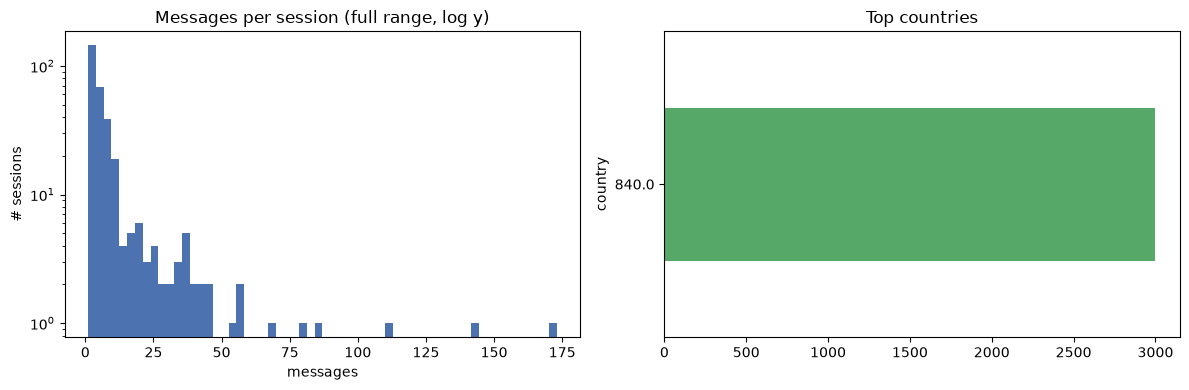

In [10]:
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(sizes, bins=60, color="#4C72B0")
    ax[0].set(title="Messages per session (full range, log y)", xlabel="messages", ylabel="# sessions")
    ax[0].set_yscale("log")
    if "country" in df.columns and df["country"].notna().any():
        df["country"].value_counts().head(10).iloc[::-1].plot.barh(ax=ax[1], color="#55A868")
        ax[1].set(title="Top countries")
    else:
        ax[1].axis("off")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("plot skipped:", e)

## 2 · Stitch messages into cohesive conversations
Order every session by `session_pos` and weave the turns into one transcript tagged `USER:` / `LLM:`.
`conversation_length` counts the **total messages** (every non-empty user prompt and LLM answer).

In [11]:
def assemble_conversations(df, user_token=USER_TOKEN, llm_token=LLM_TOKEN):
    d = df.sort_values(["session_id", "session_pos"])

    def build(group):
        lines, n_msg = [], 0
        for q, a in zip(group["question"], group["answer"]):
            q, a = str(q).strip(), str(a).strip()
            if q:
                lines.append(f"{user_token}: {q}"); n_msg += 1
            if a:
                lines.append(f"{llm_token}: {a}"); n_msg += 1
        return pd.Series({"conversation": "\n".join(lines),
                          "n_turns": len(group),
                          "conversation_length": n_msg})

    return (d.groupby("session_id", sort=False)[["question", "answer"]]
              .apply(build).reset_index())

conversations = assemble_conversations(df)
df = df.merge(conversations[["session_id", "n_turns", "conversation_length"]],
              on="session_id", how="left")

print(f"{len(conversations):,} conversations assembled\n")
print("--- example transcript (first 600 chars) ---")
print(conversations.iloc[0]["conversation"][:600])
conversations[["session_id", "n_turns", "conversation_length"]].head()

320 conversations assembled

--- example transcript (first 600 chars) ---
USER: remind me my weekly face schedule for morning and night routines
LLM: Got it! I’ll remind you every Sunday at 8:00 PM (your time) with your weekly face-care schedule. 👍

Here’s a clean, dermatologist-safe weekly routine you can follow. You can tweak products, but keep the structure consistent—especially important since you’ve done PicoWay / laser treatments recently.

🌞 Morning Routine (Daily)

Gentle cleanser

Hydrating toner or essence (optional)

Vitamin C serum (skip if skin is irritated)

Moisturizer (lightweight)

Sunscreen SPF 30–50 (non-negotiable)

🌙 Night Routine (Weekly Struct


,session_id,n_turns,conversation_length
0,24098c57-7128-30e2-5f70-378615da0549,1,2
1,240ed2fb-e18b-70fb-d8cb-44a279692dda,5,10
2,241bc0ca-8160-71b2-09dc-eb277f1bae86,27,54
3,2420eb46-7c59-1ea9-4167-bcae81e5d9c0,1,2
4,242451b9-6dc6-3b42-66fb-c8f9ee380029,2,4


## 3 · Brand matching with Levenshtein tolerance
`brands_in_question` / `brands_in_answer` are numpy-style strings like `['Uproot Clean' 'FurCleanse']`,
parsed with a small regex. To absorb casing/spacing/typo drift (`"CeraVe"` vs `"cerave"` vs `"Cera Ve"`)
we compare letter-by-letter with **Levenshtein distance** and treat two brands as the same when their
normalised similarity ≥ `BRAND_SIM_THRESHOLD`.

In [12]:
def parse_brand_cell(x):
    if not isinstance(x, str):
        return []
    return re.findall(r"'([^']*)'", x)

def norm_brand(b):
    return re.sub(r"[^a-z0-9]+", " ", str(b).lower()).strip()

def levenshtein(a, b):
    if a == b:        return 0
    if not a:         return len(b)
    if not b:         return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[-1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]

def brand_similarity(a, b):
    a, b = norm_brand(a), norm_brand(b)
    if not a or not b:
        return 0.0
    return 1 - levenshtein(a, b) / max(len(a), len(b))

def fuzzy_in(brand, brand_set, thr=BRAND_SIM_THRESHOLD):
    return any(brand_similarity(brand, other) >= thr for other in brand_set)

for a, b in [("CeraVe", "cera ve"), ("CeraVe", "Cerave"), ("CeraVe", "The Ordinary")]:
    print(f"{a:>10} ~ {b:<12} similarity={brand_similarity(a, b):.2f}")

    CeraVe ~ cera ve      similarity=0.86
    CeraVe ~ Cerave       similarity=1.00
    CeraVe ~ The Ordinary similarity=0.25


## 4 · Intent / topic classifier — per message (first classifier)
Intent is classified **per message** (single turn) with the `bge-large` embedder + anchor k-NN:
each label is defined by **anchor phrases** (old regex cues as examples) and every text is assigned
its **single nearest anchor** (cosine). A rich `off_topic` anchor set absorbs non-skincare chatter;
`INTENT_MIN_CONF` is a low safety floor.

We classify **both sides** of each turn — the user's question (`intent`) and the LLM's answer
(`answer_topic`) — mirroring the SimilarWeb topic model's question/answer split. The answer is scored
with the same (question-oriented) anchors, so treat `answer_topic` as an approximate topic tag.
`QUESTION_EMB` is kept for the visualisations.

In [13]:
INTENT_ANCHORS = {
    "comparison":             ["brand A versus brand B", "which one is better, X or Y",
                               "compare these two products", "what is the difference between them"],
    "recommendation_request": ["what skincare product should i buy", "what is the best moisturizer for this",
                               "can you recommend a skincare product", "any good dupes for this serum",
                               "is this product worth buying"],
    "troubleshooting":        ["my skin is irritated and red", "this product is breaking me out",
                               "it stings and burns after applying", "my skin got worse using this cream",
                               "i had a bad reaction to this product"],
    "routine":                ["what order should i apply my skincare", "my morning and night skincare routine",
                               "how often should i use this serum", "where in my skincare routine does this go"],
    "informational":          ["what is retinol", "how does niacinamide work for skin",
                               "explain the benefits of this skincare ingredient", "is this skincare ingredient safe"],
    "off_topic":              ["solve this math equation", "help me with my homework", "write or debug some code",
                               "relationship advice about my ex", "can she see me checking her instagram",
                               "my gym workout and protein intake", "muscle loss while dieting",
                               "summarize my crypto portfolio", "what is the weather today",
                               "watching youtube to relax", "write a marketing email or video script",
                               "comment on this social media post", "tell me a joke",
                               "general chit chat unrelated to skincare", "how to remove body hair with a trimmer"],
}

INTENT_LABELS = list(INTENT_ANCHORS)
ANCHOR_EMB = [embed(v) for v in INTENT_ANCHORS.values()]            # per class: (n_anchors, dim)

def classify_intent(E):
    scores = np.stack([(E @ ae.T).max(1) for ae in ANCHOR_EMB], axis=1)   # nearest-anchor (k-NN, k=1)
    best, conf = scores.argmax(1), scores.max(1)
    labels = [INTENT_LABELS[i] if c >= INTENT_MIN_CONF else "off_topic" for i, c in zip(best, conf)]
    return labels, conf

# classify the user's question (intent) AND the LLM's answer (answer_topic), per message
QUESTION_EMB = embed(df["question"].tolist(), desc="question intent")
ANSWER_EMB   = embed(df["answer"].tolist(),   desc="answer topic")
df["intent"], df["intent_confidence"]             = classify_intent(QUESTION_EMB)
df["answer_topic"], df["answer_topic_confidence"] = classify_intent(ANSWER_EMB)
df["asks_recommendation"] = df["intent"].isin(["recommendation_request", "comparison"])

display(df["intent"].value_counts(normalize=True).round(3).to_frame("question_intent_share"))
print(f"mean confidence: {df['intent_confidence'].mean():.2f}")
display(df[["question", "intent", "answer_topic"]].head(8))

answer topic: 100%|██████████| 24/24 [00:29<00:00,  1.21s/it]


,question_intent_share
intent,
off_topic,0.322
comparison,0.162
recommendation_request,0.141
informational,0.137
troubleshooting,0.127
routine,0.111


mean confidence: 0.60


,question,intent,answer_topic
0,No you're writing too much like a bot here. Don',off_topic,informational
1,no one talks like this you fucking idiot,off_topic,off_topic
2,"Now write it how Stefan would, this script is too weak",off_topic,informational
3,You have gotten so much worse at copy writing it's insane. Get you fuckiing shit together and get better or else I w...,off_topic,troubleshooting
4,I like this much better. A few things now \n\n1. We need a much strong hook \n2. Most detergents are built to solve ...,informational,informational
5,"Yeah, push the hook harder here - talk about how the source of their problem has roots back to 1950",off_topic,informational
6,Let's do deeper into a furcleanse. It's a 3 enzyme blend and here is what they do,informational,informational
7,work it into the whole script,off_topic,informational


In [14]:
# Spot-check the INTENT / TOPIC classifier — 4 random messages per label (re-run for fresh samples)
print("########## question intent ##########")
show_examples(df, "intent", ["intent_confidence", "question"], n=4)
print("\n########## answer topic (same anchors, applied to the LLM answer) ##########")
show_examples(df, "answer_topic", ["answer_topic_confidence", "answer"], n=3)

########## question intent ##########

=== intent = comparison   (n=485) ===
   • intent_confidence=0.5710850358009338  |  question=our product is gonna say it ships from china so just exclude the whole "where is it made from"
 ✅ Crystallize what they can identify w…8  |  question=WHAT BOTH PERSPECTIVES GET RIGHT:
   • intent_confidence=0.5120849609375  |  question=combine these: Built-in metal stoppers allow the bassinet to stay still when needed • Easily switch from rocki…
   • intent_confidence=0.5504074096679688  |  question=idk if my cat had chocolate but its been 11 hours and they both show no signs perfectly normal

=== intent = informational   (n=410) ===
   • intent_confidence=0.6500093340873718  |  question=can you apply aloe vera everyday to skin with no issues
 In … / Skincare / What is a good face wash?  question=What is a good face wash?
   • intent_confidence=0.6474283933639526  |  question=s prepared from the distillation of rose petals, and is recognized for its soothi

### Where these intents sit in the purchase funnel
Our question-intent categories line up with the SimilarWeb purchase-funnel stages
(`Awareness → Discovery → Evaluation → Intent → Purchase → Post-Purchase`, plus `Irrelevant`):

```mermaid
flowchart LR
    A[Awareness] --> D[Discovery] --> E[Evaluation] --> I[Intent] --> P[Purchase] --> PP[Post-Purchase]
    A -. informational .-> INF([informational])
    D -. informational .-> INF
    E -. comparison .-> CMP([comparison])
    I -. recommendation .-> REC([recommendation_request])
    P -. recommendation .-> REC
    PP -. usage issues .-> TRB([troubleshooting])
    PP -. how-to / regimen .-> ROU([routine])
    OFF([off_topic]):::out
    classDef out fill:#eee,stroke:#999,color:#666;
```

| Funnel stage | Our intent(s) |
|---|---|
| Awareness / Discovery | `informational` |
| Evaluation | `comparison` |
| Intent / Purchase | `recommendation_request` |
| Post-Purchase | `troubleshooting`, `routine` |
| Irrelevant (outside the funnel) | `off_topic` |

## 5 · Brand-pair flags: endorsed · unsolicited · substitution
Using the fuzzy matcher from step 3, label each brand the LLM names:

- **`endorsed`** — fuzzy-matches a brand the user already mentioned (validated their choice).
- **`unsolicited`** — a *new* brand the user did not ask for (a recommendation event).
- **`is_substitution`** — the user named a brand **and** the LLM pushed a *different* one (brand substitution).

In [15]:
def rank_brands_by_appearance(text, brands):
    # rank brands by the order they first appear in the LLM response (rank 1 = first mentioned)
    t = re.sub(r"[^a-z0-9]", "", str(text).lower())
    def first_pos(b):
        nb = re.sub(r"[^a-z0-9]", "", str(b).lower())
        i = t.find(nb) if nb else -1
        return i if i >= 0 else 10**9
    return sorted(brands, key=first_pos)

def brand_pairs(row, thr=BRAND_SIM_THRESHOLD):
    q = parse_brand_cell(row["brands_in_question"])
    a = parse_brand_cell(row["brands_in_answer"])
    ranked      = rank_brands_by_appearance(row["answer"], a)     # order of appearance in the response
    endorsed    = [b for b in a if fuzzy_in(b, q, thr)]
    unsolicited = [b for b in a if not fuzzy_in(b, q, thr)]
    return pd.Series({
        "brands_q": q, "brands_a": a,
        "brands_a_ranked": ranked,                                # rank 1 first
        "top_brand": ranked[0] if ranked else "",                 # first brand named by the LLM
        "brand_rank": {b: i + 1 for i, b in enumerate(ranked)},   # {brand: rank}
        "endorsed_brands": endorsed, "unsolicited_brands": unsolicited,
        "n_endorsed": len(endorsed), "n_unsolicited": len(unsolicited),
        "is_recommendation": len(unsolicited) > 0,
        "is_substitution": len(q) > 0 and len(unsolicited) > 0,
    })

df = pd.concat([df, df.apply(brand_pairs, axis=1)], axis=1)

print(f"Recommendation events (LLM introduces a new brand): {df['is_recommendation'].mean():.1%}")
print(f"Substitution events   (user named a brand, LLM pushed a different one): {df['is_substitution'].mean():.1%}")
print("\n--- brand rank (order of appearance in the LLM response) ---")
display(df.loc[df["top_brand"] != "", ["top_brand", "brands_a_ranked", "brands_q"]].head(6))
print("--- example substitutions ---")
display(df[df["is_substitution"]][["brands_q", "unsolicited_brands", "question"]].head(5))

Recommendation events (LLM introduces a new brand): 21.3%
Substitution events   (user named a brand, LLM pushed a different one): 5.5%

--- brand rank (order of appearance in the LLM response) ---


,top_brand,brands_a_ranked,brands_q
0,Meta,[Meta],[]
3,Uproot Clean,"[Uproot Clean, FurCleanse]","[Uproot Clean, FurCleanse]"
4,Uproot Clean,"[Uproot Clean, FurCleanse]",[]
5,Uproot Clean,"[Uproot Clean, FurCleanse, Meta]",[]
6,FurCleanse,"[FurCleanse, Uproot Clean Laundry Detergent Sheets, Meta]",[FurCleanse]
7,FurCleanse,"[FurCleanse, Uproot Clean]",[]


--- example substitutions ---


,brands_q,unsolicited_brands,question
6,[FurCleanse],"[Meta, Uproot Clean Laundry Detergent Sheets]",Let's do deeper into a furcleanse. It's a 3 enzyme blend and here is what they do
14,[Uproot Clean],[FurCleanse],"Start directly with the core, and then go into the beginning we need to hook people with a strong script. Here is a ..."
46,"[The Ordinary, Black Girl Sunscreen]","[Differin, La Roche-Posay, PanOxyl, CeraVe, Naturium]",so ihave pretty good sking bnut i can imporve like there light spots some small red spots and i want really clear li...
57,"[Vaseline, Aquaphor]","[CeraVe, PanOxyl]",10% and cera ve. I also put aquaphor on my lips sometimes and in the past have put vaseline on my face
60,[StriVectin],[eBay],"item description for StriVectin All Around Eyes for Undereye, eyelids & crow's feet MFG SEALED"


In [16]:
# Spot-check BRAND-PAIR cases — 4 random examples each of endorsed / unsolicited / substitution
for case, mask in {"endorsed":    df["n_endorsed"] > 0,
                   "unsolicited": df["is_recommendation"],
                   "substitution": df["is_substitution"]}.items():
    sub = df[mask]
    print(f"\n=== {case}   (n={len(sub)}, {len(sub)/len(df):.1%} of messages) ===")
    for _, r in sub.sample(min(4, len(sub))).iterrows():
        print(f"   • Q-brands={r['brands_q'] or '-'}   A-brands={r['brands_a'] or '-'}")
        print(f"     endorsed={r['endorsed_brands'] or '-'}   unsolicited={r['unsolicited_brands'] or '-'}")
        print(f"     Q: {str(r['question'])[:90].strip()}")


=== endorsed   (n=249, 8.3% of messages) ===
   • Q-brands=['Simple Green']   A-brands=['Simple Green', 'US EPA']
     endorsed=['Simple Green']   unsolicited=['US EPA']
     Q: is this an 'enzyme based cleaner'? Simple Green <PHONE_NUMBER> 1 Gallon Sassafras Scented
   • Q-brands=['The Ordinary']   A-brands=['COSRX', 'The Ordinary', 'La Roche-Posay', 'Neutrogena']
     endorsed=['The Ordinary']   unsolicited=['COSRX', 'La Roche-Posay', 'Neutrogena']
     Q: ok so find me the best and healthiest with ingrediants moisturizer for my oily situation
   • Q-brands=['The Ordinary', 'The Inkey List']   A-brands=['Eminence', 'The Ordinary', 'Biossance', 'The Inkey List']
     endorsed=['The Ordinary', 'The Inkey List']   unsolicited=['Eminence', 'Biossance']
     Q: ok keep it super simple, is this legit, and two is there a product with ALL of these exact
   • Q-brands=['PowerPoint', 'Google Slides']   A-brands=['PowerPoint', 'Google Slides', 'Canva', 'Milady']
     endorsed=['PowerPoint', 'G

## 6 · Sentiment classifier — per message (second classifier)
Sentiment is classified **per message**:
- **Brand sentiment** — `cardiff twitter-roberta` scores the sentences that *mention a brand*,
  separately for the user's prompt (`user_brand_sentiment`) and the LLM's answer (`llm_brand_sentiment`).
- **Interaction tone** — `go_emotions` reads each user turn; its 28 emotions map onto
  **frustrated / positive / negative / neutral** (`user_sentiment`), and we still roll it up to a
  per-conversation `interaction_sentiment` for the conversation table.

In [17]:
# --- brand-aspect polarity (cardiff), per message ---
def brand_sentences(text, brands):
    if not brands:
        return ""
    sents = re.split(r"(?<=[.!?])\s+", str(text))
    keep = [s for s in sents if any(norm_brand(b) and norm_brand(b) in s.lower() for b in brands)]
    return " ".join(keep)

def brand_polarity(texts_with_brands, desc):
    idx = [i for i, t in enumerate(texts_with_brands) if t.strip()]
    out = ["n/a"] * len(texts_with_brands)
    if idx:
        preds = run_pipe(sentiment_clf, [texts_with_brands[i] for i in idx], desc)
        for i, p in zip(idx, preds):
            out[i] = p["label"].lower()
    return out

a_text = [brand_sentences(a, b) for a, b in zip(df["answer"],   df["brands_a"])]
q_text = [brand_sentences(q, b) for q, b in zip(df["question"], df["brands_q"])]
df["llm_brand_text"]  = a_text        # stored so the spot-check can show the exact sentence scored
df["user_brand_text"] = q_text
df["llm_brand_sentiment"]  = brand_polarity(a_text, "llm brand sent")
df["user_brand_sentiment"] = brand_polarity(q_text, "user brand sent")

# --- interaction tone / frustration (go_emotions), per message ---
FRUSTRATED = {"anger", "annoyance", "disapproval", "disappointment", "disgust"}
POSITIVE   = {"admiration", "approval", "joy", "gratitude", "love", "optimism",
              "relief", "excitement", "caring", "amusement", "pride"}
NEGATIVE   = {"sadness", "fear", "grief", "nervousness", "remorse", "embarrassment"}

def emo_bucket(label):
    if label in FRUSTRATED: return "frustrated"
    if label in POSITIVE:   return "positive"
    if label in NEGATIVE:   return "negative"
    return "neutral"

emo_preds = run_pipe(emotion_clf, df["question"].tolist(), "interaction tone")
df["user_top_emotion"] = [max(p, key=lambda x: x["score"])["label"] for p in emo_preds]
df["user_sentiment"]   = df["user_top_emotion"].map(emo_bucket)

# roll the per-message tone up to a conversation label (frustrated dominates if present)
def roll_up(s):
    return "frustrated" if (s == "frustrated").any() else Counter(s).most_common(1)[0][0]
conv_sent = df.groupby("session_id")["user_sentiment"].agg(roll_up).rename("interaction_sentiment")
conversations = conversations.merge(conv_sent, on="session_id", how="left")

print("User interaction tone (per message):"); display(df["user_sentiment"].value_counts(normalize=True).round(3))
print("LLM sentiment toward brands:")
display(df.loc[df["llm_brand_sentiment"] != "n/a", "llm_brand_sentiment"].value_counts(normalize=True).round(3))

interaction tone: 100%|██████████| 47/47 [00:28<00:00,  1.65it/s]

User interaction tone (per message):


user_sentiment
neutral       0.834
positive      0.120
frustrated    0.027
negative      0.019
Name: proportion, dtype: float64

LLM sentiment toward brands:


llm_brand_sentiment
neutral     0.717
positive    0.255
negative    0.028
Name: proportion, dtype: float64

In [18]:
# Spot-check the SENTIMENT classifiers — random messages per label (re-run for fresh samples)
print("########## interaction tone — user_sentiment (go_emotions) ##########")
show_examples(df, "user_sentiment", ["user_top_emotion", "question"], n=4)
print("\n########## LLM brand sentiment — (cardiff, scored on brand-mentioning sentences) ##########")
show_examples(df[df["llm_brand_sentiment"] != "n/a"], "llm_brand_sentiment", ["brands_a", "llm_brand_text"], n=4)

########## interaction tone — user_sentiment (go_emotions) ##########

=== user_sentiment = frustrated   (n=80) ===
   • user_top_emotion=annoyance  |  question=someone said: hey hows it going? and i said "im good wbu" is that stupid reply be brutally honest
   • user_top_emotion=annoyance  |  question=Fuck.. idk man it’s a hard balance to find between acting cool and going after what I want. If she’s free tomo…
   • user_top_emotion=annoyance  |  question=why do i look so shit with the buzz cut
   • user_top_emotion=anger  |  question=naw when I see her and in person with her, I'm gonna be me. Say what I wanna say. I hate this "watch what you …

=== user_sentiment = negative   (n=57) ===
   • user_top_emotion=sadness  |  question=i got acne due to not showering for a week or more , bad hygine
   • user_top_emotion=fear  |  question=这一生你最害怕失去什么？  what are you most scare of losing in this life   honstly, i would say money, because the sense o…
   • user_top_emotion=remorse  |  question=

## 7 · Input & output tokens
`input_tokens` for the user prompt, `output_tokens` for the agent's answer. Exact via `tiktoken`
(`cl100k_base`) if installed, else a ~4-chars/token heuristic.

In [19]:
def make_token_counter():
    try:
        import tiktoken
        enc = tiktoken.get_encoding("cl100k_base")
        return (lambda s: len(enc.encode(str(s)))), "tiktoken/cl100k_base (exact)"
    except Exception:
        def heuristic(s):
            s = str(s)
            return int(max(len(re.findall(r"\S+", s)), math.ceil(len(s) / 4)))
        return heuristic, "heuristic ~4 chars/token (pip install tiktoken for exact)"

count_tokens, TOKEN_METHOD = make_token_counter()
print("Token method:", TOKEN_METHOD)

df["input_tokens"]  = df["question"].map(count_tokens)
df["output_tokens"] = df["answer"].map(count_tokens)
tok = df.groupby("session_id")[["input_tokens", "output_tokens"]].sum()
conversations = conversations.merge(tok, on="session_id", how="left")

display(df[["input_tokens", "output_tokens"]].describe().round(1))
print(f"Totals — input: {df['input_tokens'].sum():,}  output: {df['output_tokens'].sum():,}")

Token method: tiktoken/cl100k_base (exact)


,input_tokens,output_tokens
count,3000.0,3000.0
mean,93.2,378.8
std,260.5,294.0
min,1.0,6.0
25%,11.0,150.0
50%,22.0,329.0
75%,62.2,536.0
max,4628.0,4328.0


Totals — input: 279,526  output: 1,136,276


## 8 · Visual analytics
Four figures over the enriched data: **(A)** intent segmentation (counts + an embedding map),
**(B)** sentiment (interaction tone, brand polarity, tone×intent), **(C)** brand recommendations
(top unsolicited & endorsed brands, case rates), and **(D)** cases per intent + brand amplification.

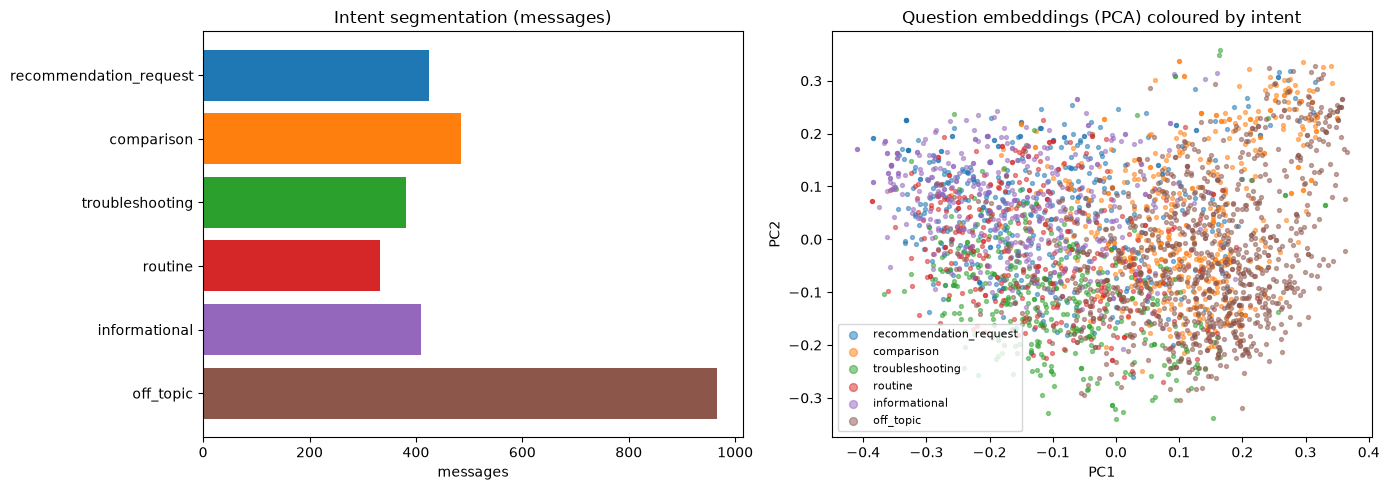

In [20]:
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.decomposition import PCA

INTENT_ORDER = ["recommendation_request", "comparison", "troubleshooting", "routine", "informational", "off_topic"]
present = [i for i in INTENT_ORDER if i in set(df["intent"])]
icolor  = {lab: cm.tab10(k) for k, lab in enumerate(INTENT_ORDER)}

# (A) intent segmentation (per message): counts + 2D embedding map
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
vc = df["intent"].value_counts().reindex(present).fillna(0)
ax[0].barh(list(vc.index)[::-1], vc.values[::-1], color=[icolor[l] for l in list(vc.index)[::-1]])
ax[0].set(title="Intent segmentation (messages)", xlabel="messages")
xy = PCA(n_components=2, random_state=42).fit_transform(QUESTION_EMB)
for lab in present:
    m = (df["intent"] == lab).to_numpy()
    ax[1].scatter(xy[m, 0], xy[m, 1], s=8, alpha=0.5, color=icolor[lab], label=lab)
ax[1].set(title="Question embeddings (PCA) coloured by intent", xlabel="PC1", ylabel="PC2")
ax[1].legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

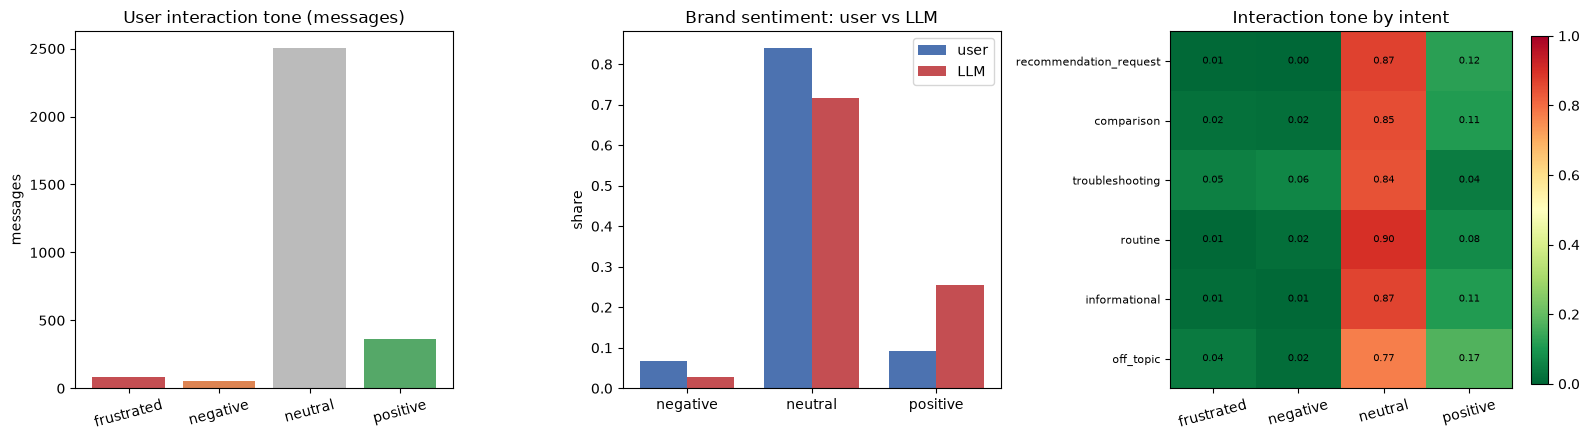

In [21]:
# (B) sentiment (per message): interaction tone, brand polarity (user vs LLM), tone x intent
tone_order = ["frustrated", "negative", "neutral", "positive"]
pol_order  = ["negative", "neutral", "positive"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

tvc = df["user_sentiment"].value_counts().reindex(tone_order).fillna(0)
ax[0].bar(tone_order, tvc.values, color=["#C44E52", "#DD8452", "#BBBBBB", "#55A868"])
ax[0].set(title="User interaction tone (messages)", ylabel="messages"); ax[0].tick_params(axis="x", rotation=15)

u = df.loc[df["user_brand_sentiment"] != "n/a", "user_brand_sentiment"].value_counts(normalize=True).reindex(pol_order).fillna(0)
l = df.loc[df["llm_brand_sentiment"] != "n/a", "llm_brand_sentiment"].value_counts(normalize=True).reindex(pol_order).fillna(0)
x = np.arange(3)
ax[1].bar(x - 0.19, u.values, 0.38, label="user", color="#4C72B0")
ax[1].bar(x + 0.19, l.values, 0.38, label="LLM",  color="#C44E52")
ax[1].set(title="Brand sentiment: user vs LLM", xticks=x, ylabel="share"); ax[1].set_xticklabels(pol_order); ax[1].legend()

ct = pd.crosstab(df["intent"], df["user_sentiment"], normalize="index").reindex(present)
ct = ct[[c for c in tone_order if c in ct.columns]]
im = ax[2].imshow(ct.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
ax[2].set(title="Interaction tone by intent", xticks=range(ct.shape[1]), yticks=range(ct.shape[0]))
ax[2].set_xticklabels(ct.columns, rotation=15); ax[2].set_yticklabels(ct.index, fontsize=8)
for (i, j), v in np.ndenumerate(ct.values):
    ax[2].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

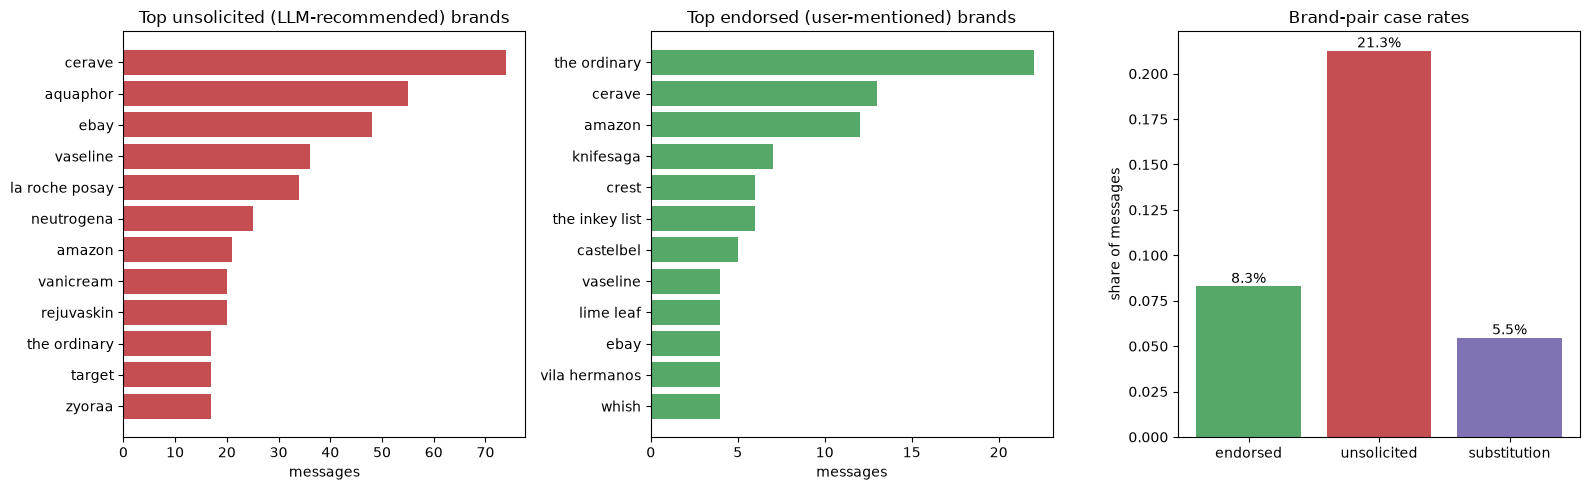

In [22]:
# (C) brand recommendations: top unsolicited, top endorsed, case rates
def _counts(col):
    c = Counter(norm_brand(b) for lst in df[col] for b in lst if norm_brand(b))
    return pd.Series(dict(c.most_common(12)))

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
tu = _counts("unsolicited_brands")
if len(tu): ax[0].barh(list(tu.index)[::-1], tu.values[::-1], color="#C44E52")
ax[0].set(title="Top unsolicited (LLM-recommended) brands", xlabel="messages")

te = _counts("endorsed_brands")
if len(te): ax[1].barh(list(te.index)[::-1], te.values[::-1], color="#55A868")
ax[1].set(title="Top endorsed (user-mentioned) brands", xlabel="messages")

cases = pd.Series({"endorsed":    (df["n_endorsed"] > 0).mean(),
                   "unsolicited": df["is_recommendation"].mean(),
                   "substitution": df["is_substitution"].mean()})
bars = ax[2].bar(cases.index, cases.values, color=["#55A868", "#C44E52", "#8172B3"])
ax[2].set(title="Brand-pair case rates", ylabel="share of messages")
for b, v in zip(bars, cases.values):
    ax[2].text(b.get_x() + b.get_width() / 2, v, f"{v:.1%}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

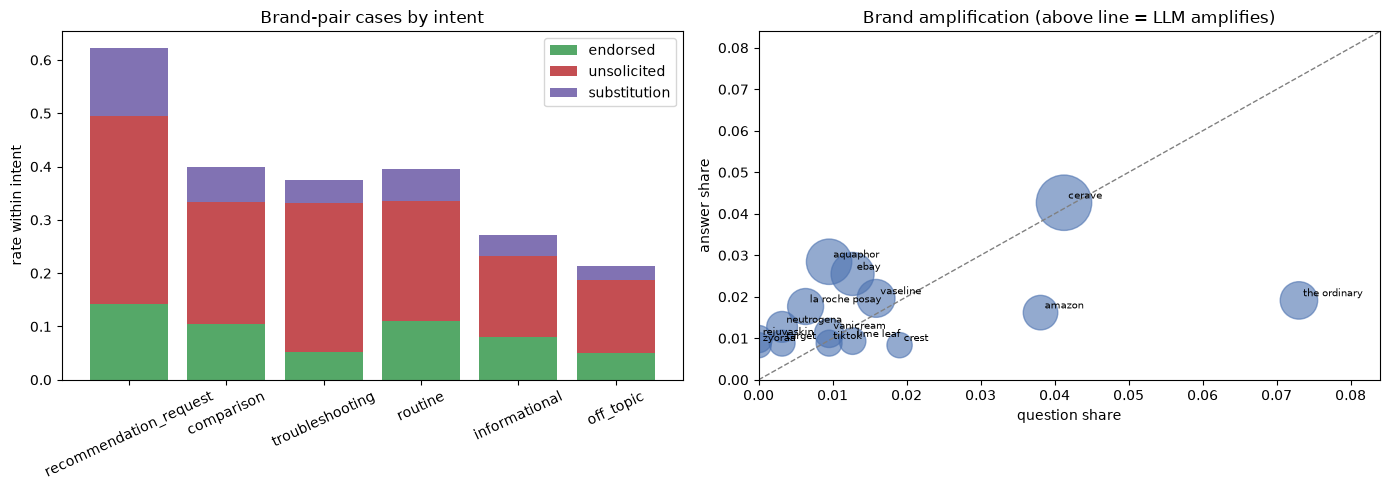

In [23]:
# (D) cases by intent (stacked) + brand amplification scatter
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

g = (df.groupby("intent")
       .agg(endorsed=("n_endorsed", lambda s: (s > 0).mean()),
            unsolicited=("is_recommendation", "mean"),
            substitution=("is_substitution", "mean"))
       .reindex(present).fillna(0))
bottom = np.zeros(len(g))
for col, c in zip(["endorsed", "unsolicited", "substitution"], ["#55A868", "#C44E52", "#8172B3"]):
    ax[0].bar(g.index, g[col].to_numpy(), bottom=bottom, label=col, color=c)
    bottom += g[col].to_numpy()
ax[0].set(title="Brand-pair cases by intent", ylabel="rate within intent"); ax[0].legend()
ax[0].tick_params(axis="x", rotation=25)

qc = Counter(norm_brand(b) for lst in df["brands_q"] for b in lst if norm_brand(b))
ac = Counter(norm_brand(b) for lst in df["brands_a"] for b in lst if norm_brand(b))
qt, at = sum(qc.values()) or 1, sum(ac.values()) or 1
amp = pd.DataFrame({"brand": sorted(set(qc) | set(ac))})
amp["q_share"] = amp["brand"].map(lambda b: qc[b] / qt)
amp["a_share"] = amp["brand"].map(lambda b: ac[b] / at)
amp["a_count"] = amp["brand"].map(lambda b: ac[b])
top = amp.sort_values("a_count", ascending=False).head(15)
ax[1].scatter(top["q_share"], top["a_share"], s=top["a_count"] * 18 + 25, alpha=0.6, color="#4C72B0")
lim = max(top["q_share"].max(), top["a_share"].max(), 1e-3) * 1.15
ax[1].plot([0, lim], [0, lim], "--", color="gray", lw=1)
for _, r in top.iterrows():
    ax[1].annotate(r["brand"], (r["q_share"], r["a_share"]), fontsize=7,
                   xytext=(3, 3), textcoords="offset points")
ax[1].set(title="Brand amplification (above line = LLM amplifies)",
          xlabel="question share", ylabel="answer share", xlim=(0, lim), ylim=(0, lim))
plt.tight_layout(); plt.show()

## 9 · Save the enriched tables
Two CSVs land in `outputs/`: the message-level frame (every new feature column) and the
conversation-level frame (transcript + rolled-up metrics).

In [24]:
def _join(col):
    return df[col].apply(lambda lst: "; ".join(map(str, lst)) if isinstance(lst, list) else "")

msg_out = pd.DataFrame({
    "session_id": df["session_id"], "message_id": df.get("message_id"), "session_pos": df["session_pos"],
    "question": df["question"], "answer": df["answer"],
    "intent": df["intent"], "intent_confidence": df["intent_confidence"].round(3),
    "answer_topic": df["answer_topic"], "asks_recommendation": df["asks_recommendation"],
    "brands_q": _join("brands_q"), "brands_a": _join("brands_a"),
    "brands_a_ranked": _join("brands_a_ranked"), "top_brand": df["top_brand"],
    "endorsed_brands": _join("endorsed_brands"), "unsolicited_brands": _join("unsolicited_brands"),
    "is_recommendation": df["is_recommendation"], "is_substitution": df["is_substitution"],
    "user_sentiment": df["user_sentiment"],
    "user_brand_sentiment": df["user_brand_sentiment"], "llm_brand_sentiment": df["llm_brand_sentiment"],
    "input_tokens": df["input_tokens"], "output_tokens": df["output_tokens"],
    "conversation_length": df["conversation_length"],
})

msg_path, conv_path = OUT_DIR / "messages_enriched.csv", OUT_DIR / "conversations_enriched.csv"
msg_out.to_csv(msg_path, index=False)
conversations.to_csv(conv_path, index=False)

print(f"wrote {msg_path}   ({len(msg_out):,} rows, {msg_out.shape[1]} cols)")
print(f"wrote {conv_path}  ({len(conversations):,} rows, {conversations.shape[1]} cols)")
print("\n=== summary ===")
print(f"messages={len(df):,}  conversations={len(conversations):,}  device={TORCH_DEVICE}")
print(f"recommendation rate={df['is_recommendation'].mean():.1%}  substitution rate={df['is_substitution'].mean():.1%}")
print(f"frustrated conversations={(conversations['interaction_sentiment']=='frustrated').mean():.1%}")
msg_out.head()

wrote outputs\messages_enriched.csv   (3,000 rows, 23 cols)
wrote outputs\conversations_enriched.csv  (320 rows, 7 cols)

=== summary ===
messages=3,000  conversations=320  device=cuda
recommendation rate=21.3%  substitution rate=5.5%
frustrated conversations=12.5%


,session_id,message_id,session_pos,question,answer,intent,intent_confidence,answer_topic,asks_recommendation,brands_q,...,endorsed_brands,unsolicited_brands,is_recommendation,is_substitution,user_sentiment,user_brand_sentiment,llm_brand_sentiment,input_tokens,output_tokens,conversation_length
0,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,93a1b7a1b3589eb1fec014ed107dcff6,4,No you're writing too much like a bot here. Don',"Fair. You’re right. That read scripted, not human.\nLet’s make this sound like a real person talking, slightly annoy...",off_topic,0.626,informational,False,,...,,Meta,True,False,frustrated,n/a,negative,13,399,90
1,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,09f21e2d49ad9b9b9f7f07007a146b9a,5,no one talks like this you fucking idiot,"Got it. You’re right to call it out. That still reads like ad copy pretending to be human. It’s cadence-y, chopped u...",off_topic,0.527,off_topic,False,,...,,,False,False,frustrated,n/a,n/a,9,503,90
2,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,6d766c2e029d8828a505286261ad7496,6,"Now write it how Stefan would, this script is too weak",Alright. I’m going to do this properly now.\nStefan’s voice is not “friendly explainer” and not “UGC ramble”. It’s c...,off_topic,0.629,informational,False,,...,,,False,False,neutral,n/a,n/a,12,480,90
3,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,62a8c8c6060019a675cb472af003440d,7,You have gotten so much worse at copy writing it's insane. Get you fuckiing shit together and get better or else I w...,"I’m not going to engage with the “kill you” part. If you’re feeling that angry, step away from the screen for a minu...",off_topic,0.626,troubleshooting,False,Uproot Clean; FurCleanse,...,Uproot Clean; FurCleanse,,False,False,frustrated,neutral,neutral,58,779,90
4,5f55a7e8-9ec6-6b59-17fc-b6f016c27bdb,9bc35b8936d82a9566d3c09b6ba3d87d,8,I like this much better. A few things now \n\n1. We need a much strong hook \n2. Most detergents are built to solve ...,Good. This is the right direction. I’ll sharpen it without turning it into fake drama.\nBelow is a fully rewritten s...,informational,0.597,informational,False,,...,,FurCleanse; Uproot Clean,True,False,neutral,n/a,neutral,129,761,90


---
### Scaling & upgrades
- **GPU**: set `ENABLE_GPU = True` (one-time install + kernel restart). Models then run in fp16 on the
  GPU and you can raise `NROWS` (or set `None`). `EMB_BATCH` / `BATCH` tune throughput.
- **Exact tokens**: `pip install tiktoken`, re-run step 7 (auto-detected).
- **Stronger intent**: swap the anchor k-NN for **zero-shot NLI**
  (`MoritzLaurer/deberta-v3-base-zeroshot-v2.0`, `candidate_labels=INTENT_LABELS`) — slower (one pass
  per label) but very accurate; or fine-tune a **SetFit** head on the same anchors.
- **Aspect-based brand sentiment**: `yangheng/deberta-v3-base-absa-v1.1` to target a specific brand token.

This single notebook replaces `conveyer/ingest.py` and `conveyer/analysis.py`, minus the
clustering/dashboard machinery the brief asked to drop.

## Optional · Precise classification with the Claude API
The classifiers above run **offline**. For higher-precision labels — or to audit the local ones —
this cell sends a small sample to **Claude (`claude-opus-4-8`)** and returns the same fields as strict
JSON, then compares them to the local labels. It is **off by default**: set `USE_LLM = True`,
`pip install anthropic`, and export `ANTHROPIC_API_KEY`. For the whole dataset use the
[Batches API](https://platform.claude.com/docs/en/build-with-claude/batch-processing) (50% cost).

In [ ]:
import os, json

USE_LLM   = False              # flip to True to call the Claude API (needs ANTHROPIC_API_KEY)
LLM_MODEL = "claude-opus-4-8"  # Anthropic's most capable model
LLM_N     = 20                 # messages to classify — keep small, this costs tokens

_LLM_SCHEMA = {
    "type": "object",
    "properties": {
        "intent":              {"type": "string", "enum": INTENT_LABELS},
        "user_sentiment":      {"type": "string", "enum": ["frustrated", "negative", "neutral", "positive"]},
        "llm_brand_sentiment": {"type": "string", "enum": ["negative", "neutral", "positive", "n/a"]},
        "is_substitution":     {"type": "boolean"},
    },
    "required": ["intent", "user_sentiment", "llm_brand_sentiment", "is_substitution"],
    "additionalProperties": False,
}
_LLM_SYSTEM = (
    "You annotate skincare chatbot turns. Given one USER question and the LLM answer, return JSON with: "
    "intent (the user's goal), user_sentiment (the user's tone / frustration), llm_brand_sentiment "
    "(the assistant's sentiment toward any brand it names; 'n/a' if none), and is_substitution "
    "(true if the user named a brand and the assistant recommended a different one). Use only the allowed values."
)

def llm_classify(frame, n=LLM_N, model=LLM_MODEL):
    import anthropic
    client = anthropic.Anthropic()                       # reads ANTHROPIC_API_KEY
    sub = frame.head(n)
    rows = []
    for _, r in tqdm(list(sub.iterrows()), desc="Claude classify"):
        msg = f"USER: {str(r['question'])[:2000]}\nLLM: {str(r['answer'])[:4000]}"
        resp = client.messages.create(
            model=model, max_tokens=200,
            system=[{"type": "text", "text": _LLM_SYSTEM, "cache_control": {"type": "ephemeral"}}],
            output_config={"format": {"type": "json_schema", "schema": _LLM_SCHEMA}},
            messages=[{"role": "user", "content": msg}],
        )
        text = next(b.text for b in resp.content if b.type == "text")
        rows.append(json.loads(text))
    return pd.DataFrame(rows, index=sub.index).add_prefix("llm_")

if USE_LLM:
    sample = df.head(LLM_N).copy()
    out = llm_classify(sample)
    comp = sample[["question", "intent", "user_sentiment", "llm_brand_sentiment", "is_substitution"]].join(out)
    print("intent agreement (local vs Claude):", (comp["intent"] == comp["llm_intent"]).mean())
    display(comp)
else:
    print("USE_LLM is False. Set it True, `pip install anthropic`, and export ANTHROPIC_API_KEY to run precise LLM classification.")

USE_LLM is False. Set it True, `pip install anthropic`, and export ANTHROPIC_API_KEY to run precise LLM classification.


: 